# House Price Dataset EDA

This notebook performs exploratory data analysis (EDA) for the `house-price-fastapi-ml` project using `data/housing_lk.csv`.

## Goals
- Understand data shape, types, and missing values
- Explore target variable (`price_lkr`) distribution
- Inspect numerical and categorical feature behavior
- Identify quick modeling insights for iteration

## Analysis Plan

This notebook follows a compact EDA flow:
1. Load and validate the dataset.
2. Review schema, summary statistics, and missing values.
3. Profile target behavior and feature relationships.
4. Capture practical modeling takeaways for the training pipeline.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [2]:
# Robust path handling from the notebooks/ directory
DATA_PATH = Path("..") / "data" / "housing_lk.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset at: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")
df.head()

Loaded: ..\data\housing_lk.csv
Shape: (20000, 14)


,district,area,perch,bedrooms,bathrooms,kitchen_area_sqft,parking_spots,has_garden,has_ac,water_supply,electricity,floors,year_built,price_lkr
0,Polonnaruwa,Polonnaruwa Central,14,5,4,112,2,False,False,Pipe-borne,Single phase,1,2022,16236332
1,Matale,Matale Central,26,7,5,250,2,True,False,Both,Single phase,3,1987,33907509
2,Mullaitivu,Mullaitivu Central,7,3,2,77,2,True,True,Well,Single phase,1,1988,5954312
3,Anuradhapura,New Town,2,2,2,39,1,True,True,Both,Three phase,2,2024,5177534
4,Batticaloa,Batticaloa Town,20,5,4,117,1,True,True,Well,Single phase,1,1995,20182409


In [3]:
# Dataset overview
display(df.info())
display(df.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   district           20000 non-null  object
 1   area               20000 non-null  object
 2   perch              20000 non-null  int64 
 3   bedrooms           20000 non-null  int64 
 4   bathrooms          20000 non-null  int64 
 5   kitchen_area_sqft  20000 non-null  int64 
 6   parking_spots      20000 non-null  int64 
 7   has_garden         20000 non-null  bool  
 8   has_ac             20000 non-null  bool  
 9   water_supply       20000 non-null  object
 10  electricity        20000 non-null  object
 11  floors             20000 non-null  int64 
 12  year_built         20000 non-null  int64 
 13  price_lkr          20000 non-null  int64 
dtypes: bool(2), int64(8), object(4)
memory usage: 1.9+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
district,20000,25,Polonnaruwa,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,20000,69,Polonnaruwa Central,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
perch,20000.0,NaN,NaN,NaN,11.5105,8.519719,2.0,5.0,10.0,16.0,80.0
bedrooms,20000.0,NaN,NaN,NaN,3.9016,1.839426,1.0,2.0,4.0,5.0,7.0
bathrooms,20000.0,NaN,NaN,NaN,3.17165,1.530883,1.0,2.0,3.0,5.0,5.0
kitchen_area_sqft,20000.0,NaN,NaN,NaN,113.7188,69.801873,35.0,53.0,95.0,161.0,250.0
parking_spots,20000.0,NaN,NaN,NaN,1.1411,0.939167,0.0,0.0,1.0,2.0,3.0
has_garden,20000,2,True,11124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_ac,20000,2,False,10711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
water_supply,20000,3,Both,6767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Missing values summary
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df[missing_df["missing_count"] > 0]

,missing_count,missing_pct


In [5]:
# Feature typing
target_col = "price_lkr"
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Target in numeric columns:", target_col in numeric_cols)

Numeric columns: ['perch', 'bedrooms', 'bathrooms', 'kitchen_area_sqft', 'parking_spots', 'floors', 'year_built', 'price_lkr']
Categorical columns: ['district', 'area', 'has_garden', 'has_ac', 'water_supply', 'electricity']
Target in numeric columns: True


## Data Profiling Snapshot

At this point we have:
- confirmed feature typing for numerical and categorical inputs
- validated that the target column is present
- enough metadata to guide preprocessing and model pipeline design

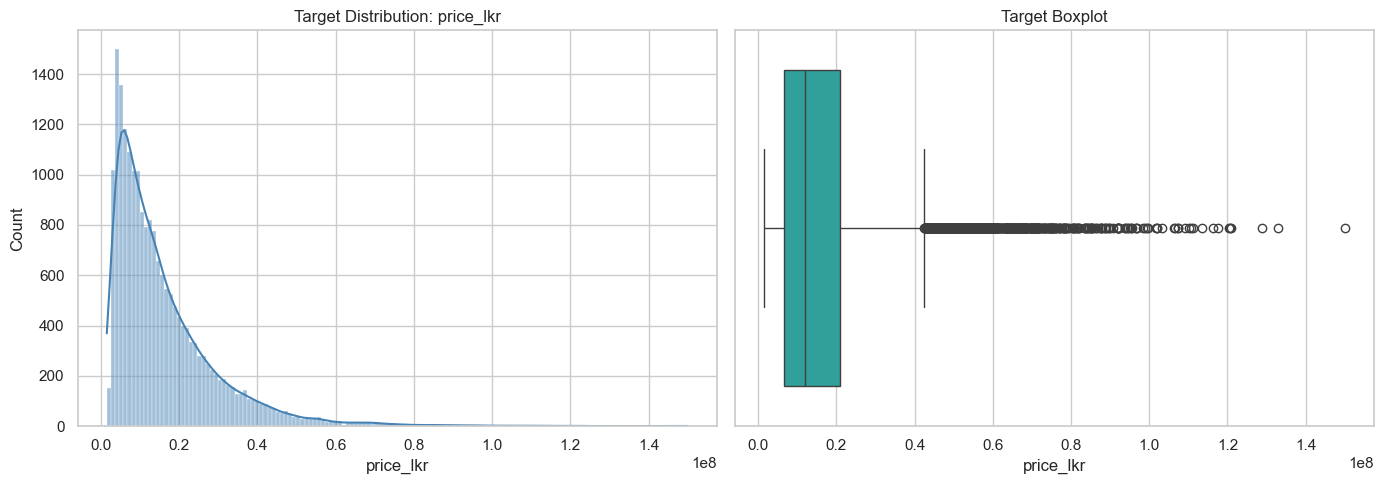

In [6]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[target_col], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Target Distribution: price_lkr")
axes[0].set_xlabel("price_lkr")

sns.boxplot(x=df[target_col], ax=axes[1], color="lightseagreen")
axes[1].set_title("Target Boxplot")
axes[1].set_xlabel("price_lkr")

plt.tight_layout()
plt.show()

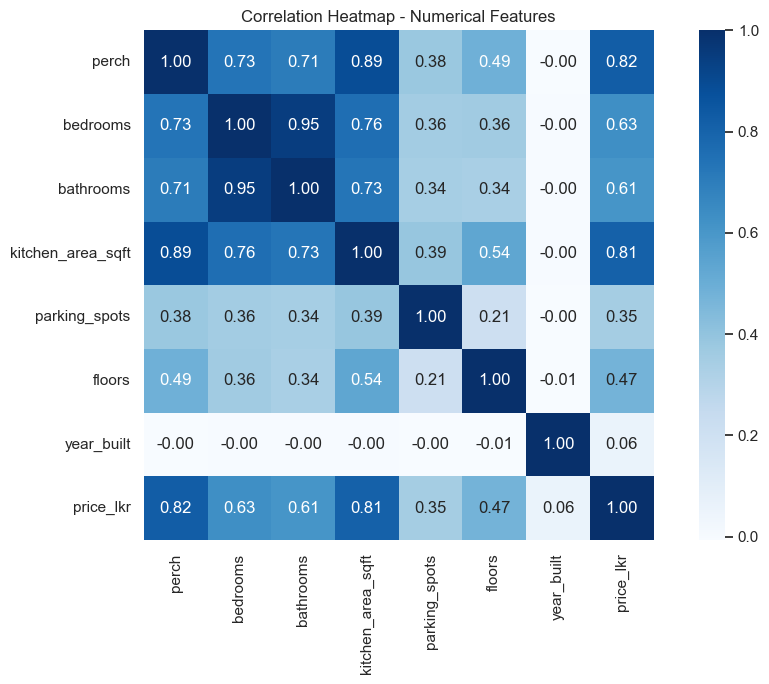

In [7]:
# Correlation heatmap (numerical features)
corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", square=True)
plt.title("Correlation Heatmap - Numerical Features")
plt.tight_layout()
plt.show()

## Relationship Analysis

The next charts focus on signal strength between core numeric features and `price_lkr`.
These visuals help identify potentially informative variables and non-linear patterns for later model tuning.

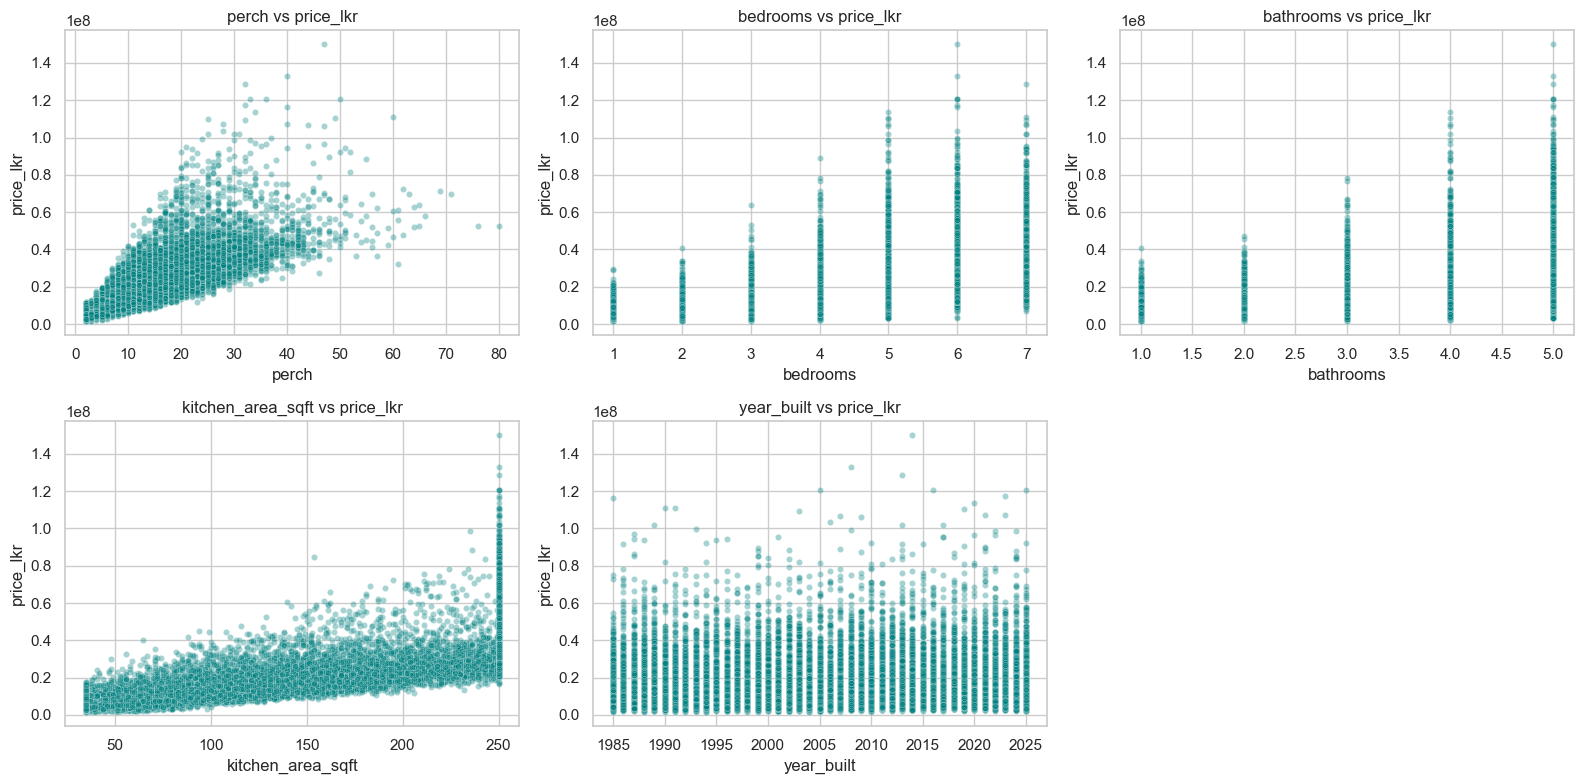

In [8]:
# Relationship between selected numerical features and target
key_numeric = ["perch", "bedrooms", "bathrooms", "kitchen_area_sqft", "year_built"]
key_numeric = [c for c in key_numeric if c in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(key_numeric) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(key_numeric):
    sns.scatterplot(data=df, x=col, y=target_col, alpha=0.35, s=20, ax=axes[i], color="teal")
    axes[i].set_title(f"{col} vs {target_col}")

for j in range(len(key_numeric), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

,n_unique,sample_values
area,69,"[Polonnaruwa Central, Matale Central, Mullaiti..."
district,25,"[Polonnaruwa, Matale, Mullaitivu, Anuradhapura..."
water_supply,3,"[Pipe-borne, Both, Well]"
has_garden,2,"[False, True]"
has_ac,2,"[False, True]"
electricity,2,"[Single phase, Three phase]"


C:\Users\a12u\AppData\Local\Temp\ipykernel_19740\2114759729.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")


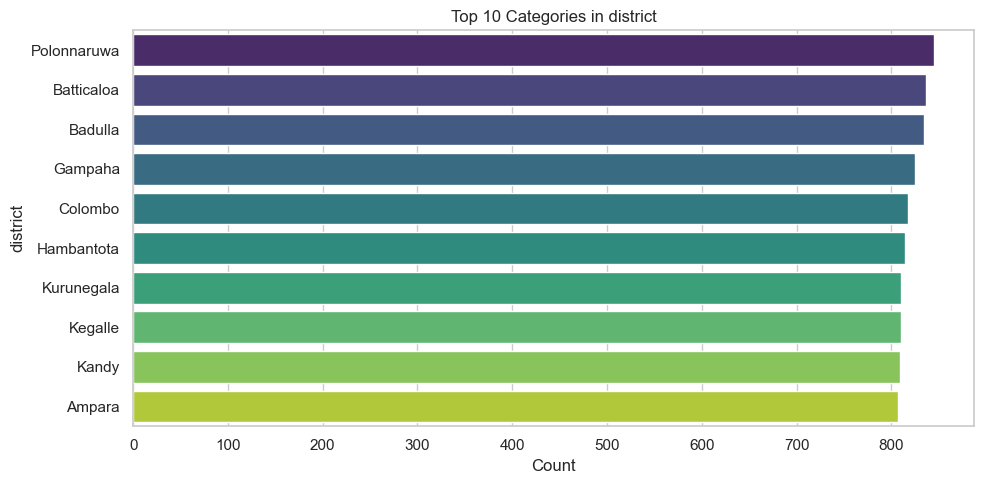

In [9]:
# Categorical overview: cardinality and top categories
if categorical_cols:
    cat_summary = pd.DataFrame({
        "n_unique": df[categorical_cols].nunique(),
        "sample_values": [df[c].dropna().astype(str).unique()[:5].tolist() for c in categorical_cols]
    }).sort_values("n_unique", ascending=False)
    display(cat_summary)

    top_cat = "district" if "district" in categorical_cols else categorical_cols[0]
    top_counts = df[top_cat].value_counts().head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")
    plt.title(f"Top 10 Categories in {top_cat}")
    plt.xlabel("Count")
    plt.ylabel(top_cat)
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found.")

## EDA Findings And Next Steps

### Key observations
- `price_lkr` shows a wide spread, suggesting the need for robust error metrics and possible target transformation experiments.
- Numeric variables such as `perch`, `kitchen_area_sqft`, and `bedrooms` appear to carry strong predictive signal.
- Categorical location fields (`district`, `area`) are likely high-impact features that should be handled carefully for unseen categories.

### Modeling implications
- Keep preprocessing and model in one pipeline artifact for reliable serving.
- Compare baseline Random Forest with gradient boosting methods.
- Test whether a log-target variant improves MAE/RMSE stability.

### Production follow-up
- Add input schema validation rules in the API layer.
- Add drift checks for key numeric distributions and category frequency shifts.
- Track experiments to compare model versions consistently.